In [12]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [13]:
# allows change in src/ to be reflected in notebook without restarting kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [15]:
from metrics import split_chips, ndvi, metrics, tune_threshold
from prepare import load_chips

chips = load_chips()
train_chips, val_chips, test_chips = split_chips(chips)

train 608 / val 192 / test 224


In [16]:
best_t = tune_threshold(train_chips)

nd_test = np.concatenate([ndvi(c["img"]).ravel() for c in test_chips])
truth_test = np.concatenate([c["msk"].ravel() for c in test_chips])
lc8_test = np.concatenate([c["lc8"].ravel() for c in test_chips])

baseline = metrics(nd_test > best_t, truth_test)
baseline

threshold -0.02, train F1 0.750


{'iou': np.float64(0.4895912126423909),
 'precision': np.float64(0.6536987446990514),
 'recall': np.float64(0.6610417862598273),
 'f1': np.float64(0.6573497589335495)}

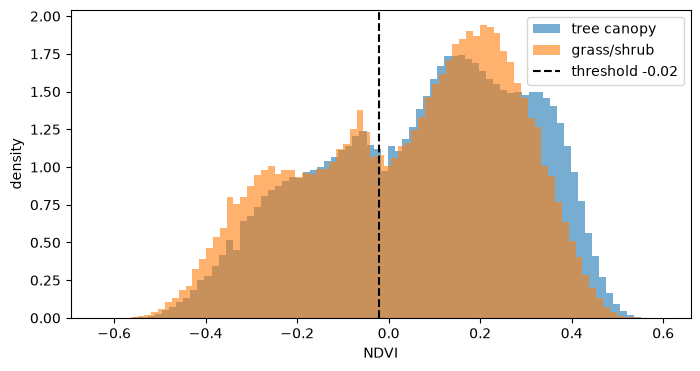

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(nd_test[lc8_test == 1], bins=80, alpha=0.6, density=True, label="tree canopy")
plt.hist(nd_test[lc8_test == 2], bins=80, alpha=0.6, density=True, label="grass/shrub")
plt.axvline(best_t, color="k", ls="--", label=f"threshold {best_t:.2f}")
plt.xlabel("NDVI")
plt.ylabel("density")
plt.legend()

plt.savefig(config.FIGURES / "02_ndvi_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
names = {1: "tree canopy", 2: "grass/shrub", 3: "bare ground", 4: "water",
         5: "building", 6: "road", 7: "other impervious", 8: "railroad"}

pred_test = nd_test > best_t

# false positives can be any non-canopy class, so the breakdown is informative
fp = pred_test & (truth_test == 0)
classes, counts = np.unique(lc8_test[fp], return_counts=True)
print("false positives (called canopy, wasn't):")
for cls, n in zip(classes, counts):
    print(f"  {names[cls]:18s} {100 * n / counts.sum():5.1f}%")

# false negatives are all class 1 by definition, so ask a different question:
# is it the turned crowns specifically that get missed?
fn = ~pred_test & (truth_test == 1)
hit = pred_test & (truth_test == 1)
print(f"\ncanopy missed: {100 * fn.sum() / (truth_test == 1).sum():.1f}%")
print(f"  median NDVI, canopy found:  {np.median(nd_test[hit]):.3f}")
print(f"  median NDVI, canopy missed: {np.median(nd_test[fn]):.3f}")

false positives (called canopy, wasn't):
  grass/shrub         50.3%
  bare ground          1.0%
  building            12.9%
  road                 9.1%
  other impervious    26.7%

canopy missed: 33.9%
  median NDVI, canopy found:  0.206
  median NDVI, canopy missed: -0.174


NVDI ran on the input chips show fales positives indentifying pixels labeled as canopy that were not; the canopy missed value looks at false negatives, comparing the median NDVI between detected and undetected canopy. IoU varies substantially by location (0.53–0.70) even at zero shift. Confirmed not a registration artifact — see below. Lower scores correspond to sparse street-tree canopy versus solid blocks; edge pixels are a larger fraction of area for narrow crowns.